# Script to extract and visualize ICES data at CodeBlue station points
- Input file format: station.csv + ./ICESData_for_validation/{var}_{year}.parquet
- Output file format: {station}.nc
  
- ICES data have been downloaded via: https://data.ices.dk/view-map. Dataset: Ocean hydrochemistry/Bottle and Low Resolution CTD Data.  
- This script have already been processed for the period 1960-2025 and variables: Oxy, NOx, NH4, PO4, SiO, Chl, Temp, Sal, SPM, pH, TA, secchi.
####  Structure:  
1. Reads the target station list from a CSV file.
2. Visualizes the stations by station type.
3. Reads ICES Parquet files for the selected variables and years.
4. Matches observations to the nearest target station using a **distance tolerance in kilometres**.
5. Keeps all available depths and adds `station`, `lat`, and `lon` to the output.
6. Combines all variables and years into **one netCDF file per station**. Dimensions(time,depth)  

- Output .nc files are available in **GoogleDrive/2025_CodeBlue_project/WP4/ICESData_for_stations**

Authors: Capet A. & Denis P.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

## 1. User settings

Update the three paths below. The ICES input folder should contain files such as
`oxy_2020.parquet`, `temp_2020.parquet`, etc.


In [2]:
datadir = Path("/hpcperm/bel9956/codeblue/ICESData_for_validation/") #input directory with ICES parquet files
station_file = Path("stations.csv") #station table
outdir = Path("/hpcperm/bel9956/codeblue/ICESData_for_stations/") #output directory where output parquet files are written

variables = ['oxy', 'nox', 'nh4', 'po4', 'sio', 'chl', 'temp', 'sal', 'spm', 'ph', 'talk', 'sec']
years = range(1960, 2025+1)

# Maximum distance between an ICES observation and a target station.
tolerance_km = 2.0 #km /!\ TO BE DISCUSSED

# Keep observations with quality flag <= MAX_QV
MAX_QV = 1

## 2. Read the station list

The station CSV is assumed to contain exactly these columns:
`station`, `lat`, `lon`, `type`.


In [3]:
# ==============================================================================
# READ STATIONS
# ==============================================================================
stations = pd.read_csv(station_file)

stations = stations[["station", "lat", "lon", "type"]].copy()

stations["lat"] = pd.to_numeric(stations["lat"])
stations["lon"] = pd.to_numeric(stations["lon"])

stations = stations.dropna(subset=["station", "lat", "lon"])

print(f"Number of stations: {len(stations)}")
print("\nStations by type:")
display(stations["type"].value_counts())

display(stations.head())

Number of stations: 128

Stations by type:


type
HELCOM_optional    40
OSPAR_optional     32
WP6                26
HELCOM             20
OSPAR              10
Name: count, dtype: int64

,station,lat,lon,type
0,LUNG_O14,54.113330,14.116671,HELCOM
1,LLUR_225058,54.315000,11.550000,HELCOM
2,LLUR_225006,54.600000,10.450000,HELCOM
3,GdanskDeep,54.833333,19.316667,HELCOM
4,TF0113,54.925000,13.500000,HELCOM


## 3. Visualize the stations

The map uses different colors for HELCOM, OSPAR and WP6 stations, while optional stations are displayed separately.

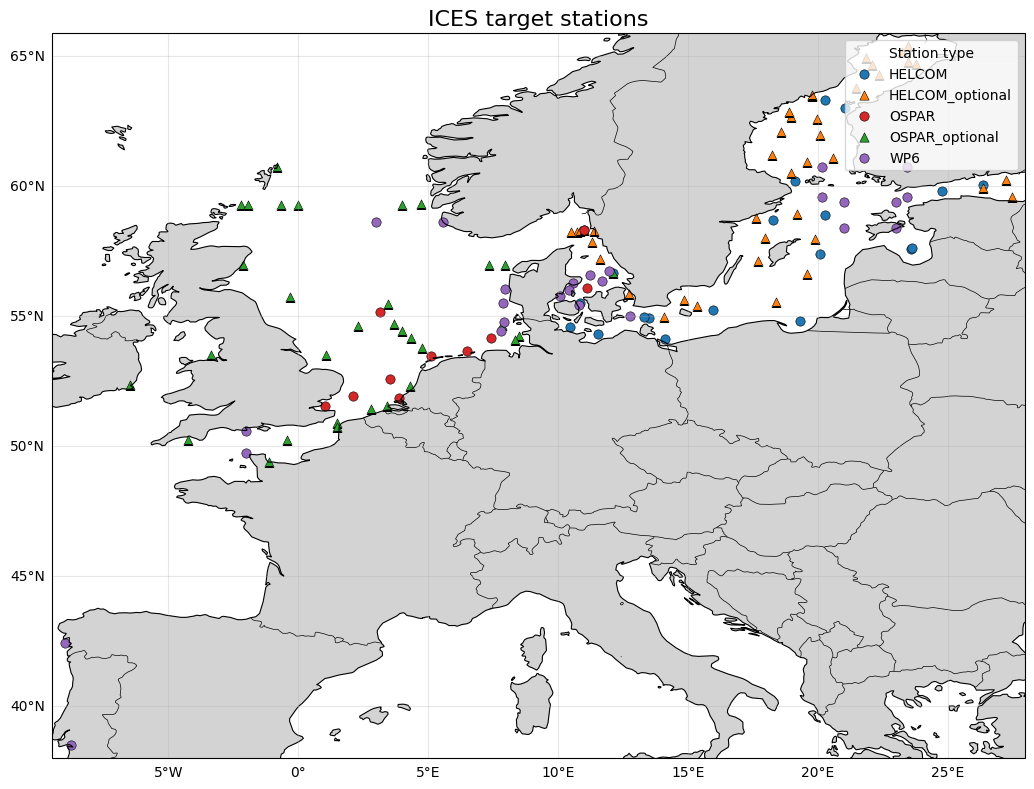

In [4]:
# ==============================================================================
# PLOT STATIONS
# ==============================================================================
def plot_stations(stations, figsize=(11, 8)):
    """Plot all target stations on a map."""

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())

    margin = 0.5

    ax.set_extent(
        [
            stations["lon"].min() - margin,
            stations["lon"].max() + margin,
            stations["lat"].min() - margin,
            stations["lat"].max() + margin,
        ],
        crs=ccrs.PlateCarree(),
    )

    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    markers = {
        "HELCOM": "o",
        "HELCOM_optional": "^",
        "OSPAR": "o",
        "OSPAR_optional": "^",
        "WP6": "o",
    }

    colors = {
        "HELCOM": "tab:blue",
        "HELCOM_optional": "tab:orange",
        "OSPAR": "tab:red",
        "OSPAR_optional": "tab:green",
        "WP6": "tab:purple",
    }

    for station_type, group in stations.groupby("type"):
        ax.scatter(
            group["lon"],
            group["lat"],
            marker=markers.get(station_type, "o"),
            color=colors.get(station_type, "gray"),
            s=45,
            edgecolor="black",
            linewidth=0.4,
            label=station_type,
            transform=ccrs.PlateCarree(),
        )

    gl = ax.gridlines(draw_labels=True, alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    ax.legend(title="Station type", loc="upper right")
    ax.set_title("ICES target stations", fontsize=16)

    plt.tight_layout()
    return fig, ax


fig, ax = plot_stations(stations)
plt.show()

## 4. Distance-based station matching

Because the ICES Parquet files do not contain the station ID, observations are associated with the **nearest target station** based on latitude/longitude.
The matching is performed using the haversine formula, so the tolerance is expressed directly in **kilometres**. 

In [5]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Return great-circle distance in kilometres.

    Inputs can be NumPy arrays. Broadcasting is supported.
    """

    earth_radius_km = 6371.0088

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2.0) ** 2
    )

    return 2.0 * earth_radius_km * np.arcsin(np.sqrt(a))

In [6]:
# ==============================================================================
# MATCH OBSERVATIONS TO TARGET STATIONS
# ==============================================================================
def match_to_stations(data, stations, tolerance_km=tolerance_km):
    """Assign each observation to its nearest target station.

    Observations farther than tolerance_km are discarded.
    """

    data = data.copy()
    data = data.dropna(subset=["lat", "lon"])

    if data.empty:
        return data

    obs_lat = data["lat"].to_numpy()[:, None]
    obs_lon = data["lon"].to_numpy()[:, None]
            
    station_lat = stations["lat"].to_numpy()[None, :]
    station_lon = stations["lon"].to_numpy()[None, :]

    distances = haversine_distance_km(
        obs_lat,
        obs_lon,
        station_lat,
        station_lon,
    )

    nearest_idx = np.argmin(distances, axis=1)
    nearest_distance = distances[
        np.arange(len(data)),
        nearest_idx,
    ]

    keep = nearest_distance <= tolerance_km

    data = data.loc[keep].copy()

    if data.empty:
        return data

    nearest_idx = nearest_idx[keep]
    nearest_distance = nearest_distance[keep]

    matched_stations = stations.iloc[nearest_idx].reset_index(drop=True)

    data["station"] = matched_stations["station"].to_numpy()
    data["station_lat"] = matched_stations["lat"].to_numpy()
    data["station_lon"] = matched_stations["lon"].to_numpy()
    data["match_distance_km"] = nearest_distance

    return data


## 5. Read and process one variable/year
The original observation `lat`/`lon` are retained, together with the target station coordinates.

In [7]:
# ==============================================================================
# READ ONE VARIABLE / YEAR
# ==============================================================================

def read_variable_year(variable, year):
    """Read one ICES variable/year Parquet file."""

    filepath = datadir / f"{variable}_{year}.parquet"

    if not filepath.exists():
        return None

    df = pd.read_parquet(filepath)
    
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True).dt.tz_localize(None)

    # Keep the columns needed for extraction.
    # The source files are expected to have this structure.
    if variable == "sec": # no quality value for secchi depth
        columns = [
            "datetime",
            "lon",
            "lat",
            "depth",
            variable,
        ]
    else:
        columns = [
            "datetime",
            "lon",
            "lat",
            "depth",
            variable,
            f"{variable}_qv",
        ]

    df = df[columns].copy()

    # Quality control
    if variable != "sec":
        df = df[df[f"{variable}_qv"] <= MAX_QV].copy()

    # Remove observations without a measurement
    df = df.dropna(subset=[variable])

    return df


def process_variable_year(variable, year):
    """Read one variable/year file and match it to target stations."""

    df = read_variable_year(variable, year)

    if df is None or df.empty:
        return None

    df = match_to_stations(
        df,
        stations,
        tolerance_km=tolerance_km,
    )

    if df.empty:
        return None

    # Keep original observation coordinates and depth.
    return df[
        [
            "station",
            "station_lat",
            "station_lon",
            "datetime",
            "lat",
            "lon",
            "depth",
            "match_distance_km",
            variable,
        ]
    ].copy()

## 6. Test the matching before processing everything

In [8]:
test_year = 2020
test_results = []

for variable in variables:
    df_test = process_variable_year(variable, test_year)

    if df_test is not None and not df_test.empty:
        test_results.append({
            "variable": variable,
            "observations": len(df_test),
            "stations": df_test["station"].nunique(),
            "mean_match_distance_km": df_test["match_distance_km"].mean(),
            "max_match_distance_km": df_test["match_distance_km"].max(),
        })

test_summary = pd.DataFrame(test_results)

display(test_summary)

,variable,observations,stations,mean_match_distance_km,max_match_distance_km
0,oxy,8546,65,1.046644,1.989799
1,nox,845,21,0.952852,1.842473
2,nh4,4190,66,1.167651,1.989799
3,po4,4458,74,1.143382,1.989799
4,sio,4464,74,1.142033,1.989799
5,chl,2708,68,1.030703,1.989799
6,temp,7130,65,0.976143,1.989799
7,sal,7528,69,0.997844,1.989799
8,ph,1011,35,0.952070,1.985320
9,talk,1143,19,1.196628,1.985320


### Optional: visualize the matched observations

This is useful for checking whether the chosen `tolerence_km` is sensible.

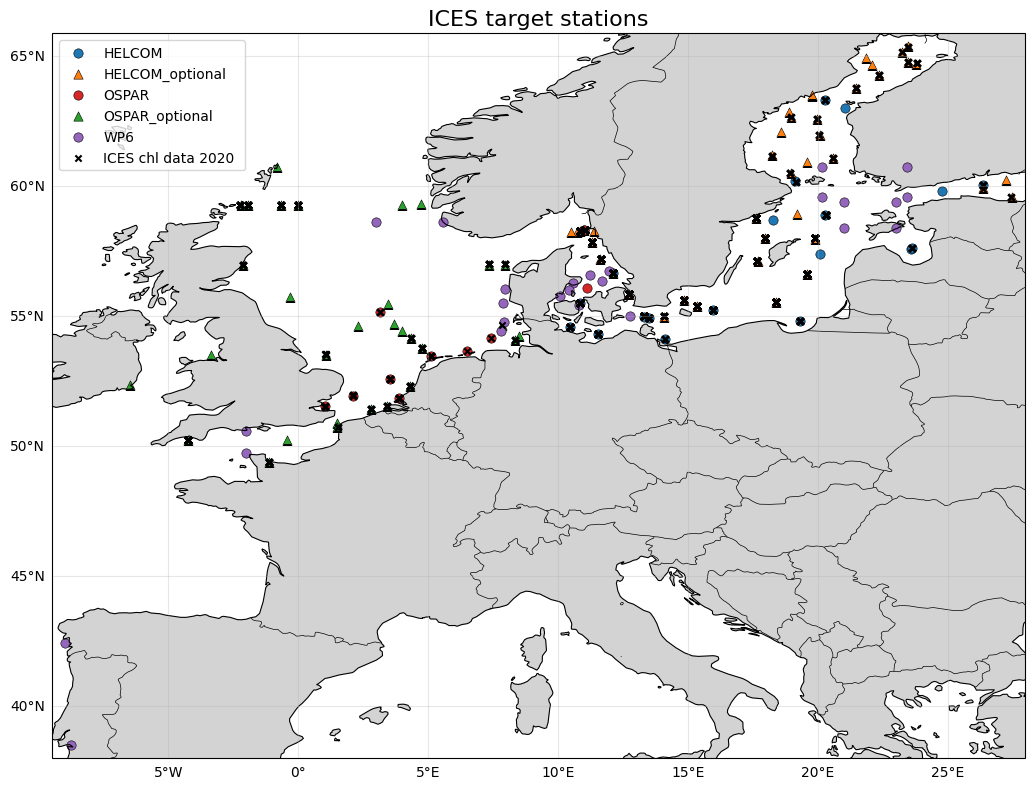

In [9]:
# ==============================================================================
# VISUALIZE MATCHED OBSERVATIONS
# ==============================================================================
test_variable = "chl"
test_df = process_variable_year(test_variable, test_year)

if test_df is not None and not test_df.empty:
    fig, ax = plot_stations(stations)

    ax.scatter(
        test_df["lon"],
        test_df["lat"],
        s=20,
        color="black",
        marker='x',
        transform=ccrs.PlateCarree(),
        label=f"ICES {test_variable} data {test_year} ",
    )

    ax.legend()
    plt.show()

## 7. Process all years and variables

The output is accumulated in memory by station. For each station, all variables and years are then combined into a single Parquet file.

The output is therefore:
```text
ICES_station_data/
├── STATION_1.parquet
├── STATION_2.parquet
├── ...
└── station_summary.csv
```

In [10]:
# ==============================================================================
# PROCESS ALL YEARS / VARIABLES
# ==============================================================================
station_data = {
    station: {
        variable: []
        for variable in variables
    }
    for station in stations["station"]
}

processing_summary = []

for year in years:

    print("=" * 70)
    print(f"Processing year: {year}")
    print("=" * 70)

    for variable in variables:

        filepath = datadir / f"{variable}_{year}.parquet"

        if not filepath.exists():
            print(f"  {variable}: file not found")
            continue

        df = process_variable_year(variable, year)

        if df is None or df.empty:
            print(f"  {variable}: no matching observations")
            continue

        # Store observations separately for each station
        for station, group in df.groupby("station"):

            station_data[station][variable].append(
                group[
                    [
                        "datetime",
                        "depth",
                        variable,
                    ]
                ].copy()
            )

        processing_summary.append({
            "year": year,
            "variable": variable,
            "observations": len(df),
            "stations": df["station"].nunique(),
        })

        print(
            f"  {variable}: {len(df):,} observations, "
            f"{df['station'].nunique()} stations"
        )

processing_summary = pd.DataFrame(processing_summary)

Processing year: 1960
  oxy: 187 observations, 7 stations
  nox: file not found
  nh4: file not found
  po4: 131 observations, 6 stations
  sio: 49 observations, 4 stations
  chl: no matching observations
  temp: 669 observations, 14 stations
  sal: 625 observations, 14 stations
  spm: file not found
  ph: 88 observations, 4 stations
  talk: 48 observations, 3 stations
  sec: file not found
Processing year: 1961
  oxy: 202 observations, 13 stations
  nox: file not found
  nh4: file not found
  po4: 29 observations, 1 stations
  sio: 26 observations, 1 stations
  chl: no matching observations
  temp: 378 observations, 17 stations
  sal: 352 observations, 17 stations
  spm: file not found
  ph: 55 observations, 3 stations
  talk: 17 observations, 1 stations
  sec: file not found
Processing year: 1962
  oxy: 433 observations, 14 stations
  nox: file not found
  nh4: no matching observations
  po4: 200 observations, 4 stations
  sio: 67 observations, 3 stations
  chl: file not found
  temp

## 8. Function to create one netCDF per station

In [11]:
def create_station_netcdf(station, station_variables, output_dir):
    """
    Create one NetCDF file for a station.

    Dimensions:
        time
        depth

    Variables:
        one variable per ICES variable.
    """

    output_dir.mkdir(parents=True, exist_ok=True)

    data_arrays = {}

    for variable, dataframes in station_variables.items():

        if not dataframes:
            continue

        # Combine all years
        df = pd.concat(dataframes, ignore_index=True)

        # Convert time/depth to appropriate types
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        df["depth"] = pd.to_numeric(df["depth"], errors="coerce")
        df[variable] = pd.to_numeric(df[variable], errors="coerce")

        # Remove invalid records
        df = df.dropna(subset=["datetime", "depth", variable])

        if df.empty:
            continue

        # ------------------------------------------------------------------
        # Handle duplicate time/depth observations
        # ------------------------------------------------------------------
        df = (df.groupby( ["datetime", "depth"], as_index=False, )[variable].mean())

        # ------------------------------------------------------------------
        # Convert to xarray DataArray
        # ------------------------------------------------------------------
        da = df.set_index(["datetime", "depth"])[variable].to_xarray()
        da = da.rename({"datetime": "time",})

        data_arrays[variable] = da

    if not data_arrays:
        print(f"{station}: no data")
        return

    # ----------------------------------------------------------------------
    # Combine all variables
    # ----------------------------------------------------------------------

    ds = xr.Dataset(data_arrays)

    # Sort dimensions
    ds = ds.sortby("time")
    ds = ds.sortby("depth")

    # ----------------------------------------------------------------------
    # Station metadata
    # ----------------------------------------------------------------------

    station_info = stations[
        stations["station"] == station
    ].iloc[0]

    ds.attrs["station"] = str(station)
    ds.attrs["station_lat"] = float(station_info["lat"])
    ds.attrs["station_lon"] = float(station_info["lon"])
    ds.attrs["description"] = ("ICES observations extracted around target station")
    ds.attrs["distance_tolerance_km"] = tolerance_km

    # ----------------------------------------------------------------------
    # Variable metadata
    # ----------------------------------------------------------------------

    variable_metadata = {
        "oxy": {
            "long_name": "Oxygen",
            "units": "ml/l",
        },
        "nox": {
            "long_name": "Nitrate + Nitrite",
            "units": "µmol/l",
        },
        "nh4": {
            "long_name": "Ammonium",
            "units": "µmol/l",
        },
        "po4": {
            "long_name": "Phosphate",
            "units": "µmol/l",
        },
        "sio": {
            "long_name": "Silicate",
            "units": "µmol/l",
        },
        "chl": {
            "long_name": "Chlorophyll a",
            "units": "µg/l",
        },
        "temp": {
            "long_name": "Temperature",
            "units": "degC",
        },
        "sal": {
            "long_name": "Salinity",
            "units": "psu",
        },
        "spm": {
            "long_name": "Suspended particulate material",
            "units": "mg/l",
        },
        "ph": {
            "long_name": "pH",
            "units": "-",
        },
        "talk": {
            "long_name": "Total Alkalinity",
            "units": "mEq/l",
        },
        "sec": {
            "long_name": "Secchi Depth",
            "units": "m",
        },
    }

    for variable in ds.data_vars:

        if variable in variable_metadata:
            ds[variable].attrs.update(variable_metadata[variable])

    # Coordinate metadata
    ds["time"].attrs["long_name"] = "Time"
    ds["depth"].attrs["long_name"] = "Depth"
    ds["depth"].attrs["units"] = "m"
    
    # ----------------------------------------------------------------------
    # Write NetCDF
    # ----------------------------------------------------------------------
    output_file = output_dir / f"{station}.nc"
    encoding = { variable: { "_FillValue": np.nan,} for variable in ds.data_vars}

    ds.to_netcdf(output_file, encoding=encoding,)

    print( f"{station}: written → {output_file}")

## 9. Run it for all stations

In [12]:
# ==============================================================================
# WRITE ONE NETCDF FILE PER STATION
# ==============================================================================

outdir.mkdir(parents=True, exist_ok=True)

for station in station_data:

    create_station_netcdf(
        station=station,
        station_variables=station_data[station],
        output_dir=outdir,
    )

LUNG_O14: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/LUNG_O14.nc
LLUR_225058: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/LLUR_225058.nc
LLUR_225006: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/LLUR_225006.nc
GdanskDeep: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/GdanskDeep.nc
TF0113: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/TF0113.nc
BY1: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/BY1.nc
BY2: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/BY2.nc
BY5_Bornholm: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/BY5_Bornholm.nc
BY4: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/BY4.nc
GreatBelt: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/GreatBelt.nc
BCS_III_10: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/BCS_III_10.nc
HANOBUKTEN: written → /hpcperm/bel9956/codeblue/ICESData_for_stations/HANOBUKTEN.nc
LANDSKRONA_W: written → /hpcperm/bel9956